# Played-in-game model

Predict the probability that a player appears in a fixture (`minutes > 0`) from the same lagged inputs as the in-season points model. Compare an unweighted CatBoost classifier with a prior-probability dummy baseline.

## Setup

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
from catboost import CatBoostClassifier, EFeaturesSelectionAlgorithm, Pool
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, brier_score_loss, log_loss, roc_auc_score

from prediction.artifacts.io import PLAYED_IN_GAME_ARTIFACT_PATH, save_trained_catboost_model
from training.config import MAX_HORIZON, NUMERIC_FEATURES, RANDOM_STATE, ROLLING_WINDOWS
from training.load_training_data import load_historic_player_fixture_data
from training.transformations import create_fixture_horizon_df, create_trended_calculations

TRAINING_SEASONS = ["2022-23", "2023-24"]
SOURCE_TARGET_COLUMN = "minutes"
TARGET_COLUMN = "played_in_game"
VALIDATION_FRACTION = 0.20
MAX_FEATURES = 20
CATEGORICAL_COLUMNS = ["position", "target_gw", "current_gw", "horizon"]
EXTRA_NUMERIC_FEATURES = [
    "transfers_balance", "selected", "value",
    "player_game_difficulty", "opponent_game_difficulty",
]
CATBOOST_PARAMS = {
    "iterations": 163,
    "learning_rate": 0.03,
    "depth": 6,
    "loss_function": "Logloss",
    "random_seed": RANDOM_STATE,
    "verbose": False,
    "allow_writing_files": False,
}


## Load and engineer data

In [2]:
fixture_history_df = pd.concat(
    [
        load_historic_player_fixture_data(season)
        .rename(columns={"GW": "target_gw"})
        .assign(season=season)
        for season in TRAINING_SEASONS
    ],
    ignore_index=True,
    sort=False,
).sort_values(["player_id", "season", "target_gw", "fixture_id"])

calculated_features_df = create_trended_calculations(
    fixture_history_df,
    rolling_windows=ROLLING_WINDOWS,
    numeric_features=NUMERIC_FEATURES + EXTRA_NUMERIC_FEATURES,
)
fixture_history_df = pd.concat(
    [fixture_history_df.reset_index(drop=True), calculated_features_df.reset_index(drop=True)],
    axis=1,
)
calculated_columns = calculated_features_df.columns.tolist()
model_features = CATEGORICAL_COLUMNS + calculated_columns
fixture_horizon_df = create_fixture_horizon_df(
    fixture_history_df=fixture_history_df,
    max_horizon=MAX_HORIZON,
    calculated_columns=calculated_columns,
    target_column=SOURCE_TARGET_COLUMN,
)
fixture_horizon_df[TARGET_COLUMN] = fixture_horizon_df[SOURCE_TARGET_COLUMN].gt(0).astype("int8")
print(fixture_horizon_df.groupby("season")[TARGET_COLUMN].agg(["size", "mean"]))


           size      mean
season                   
2022-23  275686  0.418219
2023-24  302549  0.374415


## Chronological validation split

In [3]:
fixture_gameweeks = (
    fixture_horizon_df[["season", "target_gw"]]
    .drop_duplicates()
    .sort_values(["season", "target_gw"])
)
validation_count = max(1, int(np.ceil(len(fixture_gameweeks) * VALIDATION_FRACTION)))
validation_fixture_gameweeks = pd.MultiIndex.from_frame(fixture_gameweeks.tail(validation_count))
row_fixture_gameweeks = pd.MultiIndex.from_frame(fixture_horizon_df[["season", "target_gw"]])
validation_mask = row_fixture_gameweeks.isin(validation_fixture_gameweeks)

X_train = fixture_horizon_df.loc[~validation_mask, model_features].copy()
X_valid = fixture_horizon_df.loc[validation_mask, model_features].copy()
y_train = fixture_horizon_df.loc[~validation_mask, TARGET_COLUMN].copy()
y_valid = fixture_horizon_df.loc[validation_mask, TARGET_COLUMN].copy()
for frame in (X_train, X_valid):
    frame[CATEGORICAL_COLUMNS] = frame[CATEGORICAL_COLUMNS].fillna("__MISSING__").astype(str)
print(f"Training rows: {len(X_train):,}; validation rows: {len(X_valid):,}")


Training rows: 424,119; validation rows: 154,116


## Train unweighted CatBoost and dummy baseline

In [4]:
dummy_model = DummyClassifier(strategy="prior").fit(X_train[["horizon"]], y_train)
validation_predictions = {
    "Dummy": dummy_model.predict_proba(X_valid[["horizon"]])[:, 1]
}

selector = CatBoostClassifier(**CATBOOST_PARAMS)
train_pool = Pool(X_train, y_train, cat_features=CATEGORICAL_COLUMNS)
valid_pool = Pool(X_valid, y_valid, cat_features=CATEGORICAL_COLUMNS)
target_feature_count = min(MAX_FEATURES, len(model_features))
if target_feature_count == len(model_features):
    selected_features = model_features.copy()
else:
    selection = selector.select_features(
        train_pool,
        eval_set=valid_pool,
        features_for_select=model_features,
        num_features_to_select=target_feature_count,
        steps=min(10, len(model_features) - target_feature_count),
        algorithm=EFeaturesSelectionAlgorithm.RecursiveByLossFunctionChange,
        train_final_model=False,
        verbose=False,
    )
    selected_features = selection["selected_features_names"]
selected_categorical_columns = [c for c in CATEGORICAL_COLUMNS if c in selected_features]
selected_model = CatBoostClassifier(**CATBOOST_PARAMS).fit(
    X_train[selected_features], y_train, cat_features=selected_categorical_columns
)
validation_predictions["CatBoost"] = selected_model.predict_proba(X_valid[selected_features])[:, 1]
print(f"Selected features ({len(selected_features)}): {selected_features}")


Step #1 out of 10

bestTest = 0.6387428671
bestIteration = 162

Feature #111 eliminated
Feature #222 eliminated
Feature #82 eliminated
Feature #164 eliminated
Feature #190 eliminated
Feature #136 eliminated
Feature #116 eliminated
Feature #77 eliminated
Feature #80 eliminated
Feature #94 eliminated
Feature #4 eliminated
Feature #215 eliminated
Feature #9 eliminated
Feature #25 eliminated
Feature #41 eliminated
Feature #93 eliminated
Feature #231 eliminated
Feature #132 eliminated
Feature #193 eliminated
Feature #76 eliminated
Feature #201 eliminated
Feature #178 eliminated
Feature #281 eliminated
Feature #248 eliminated
Feature #106 eliminated
Feature #126 eliminated
Feature #98 eliminated
Feature #35 eliminated
Feature #22 eliminated
Feature #95 eliminated
Feature #210 eliminated
Feature #277 eliminated
Feature #66 eliminated
Feature #232 eliminated
Feature #276 eliminated
Feature #119 eliminated
Feature #42 eliminated
Feature #166 eliminated
Feature #149 eliminated
Feature #173 elimi

## Evaluate

In [5]:
def evaluate(probability):
    predicted = np.asarray(probability)
    return {
        "log_loss": log_loss(y_valid, predicted),
        "brier_score": brier_score_loss(y_valid, predicted),
        "ROC_AUC": roc_auc_score(y_valid, predicted),
        "accuracy_at_0.5": accuracy_score(y_valid, predicted >= 0.5),
    }

comparison_table = (
    pd.DataFrame.from_dict(
        {name: evaluate(prediction) for name, prediction in validation_predictions.items()},
        orient="index",
    )
    .rename_axis("model")
    .reset_index()
    .sort_values("log_loss")
)
comparison_table.round(4)


,model,log_loss,brier_score,ROC_AUC,accuracy_at_0.5
1,CatBoost,0.6372,0.2233,0.6049,0.6460
0,Dummy,0.6572,0.2322,0.5000,0.6436


## Explain and export CatBoost model

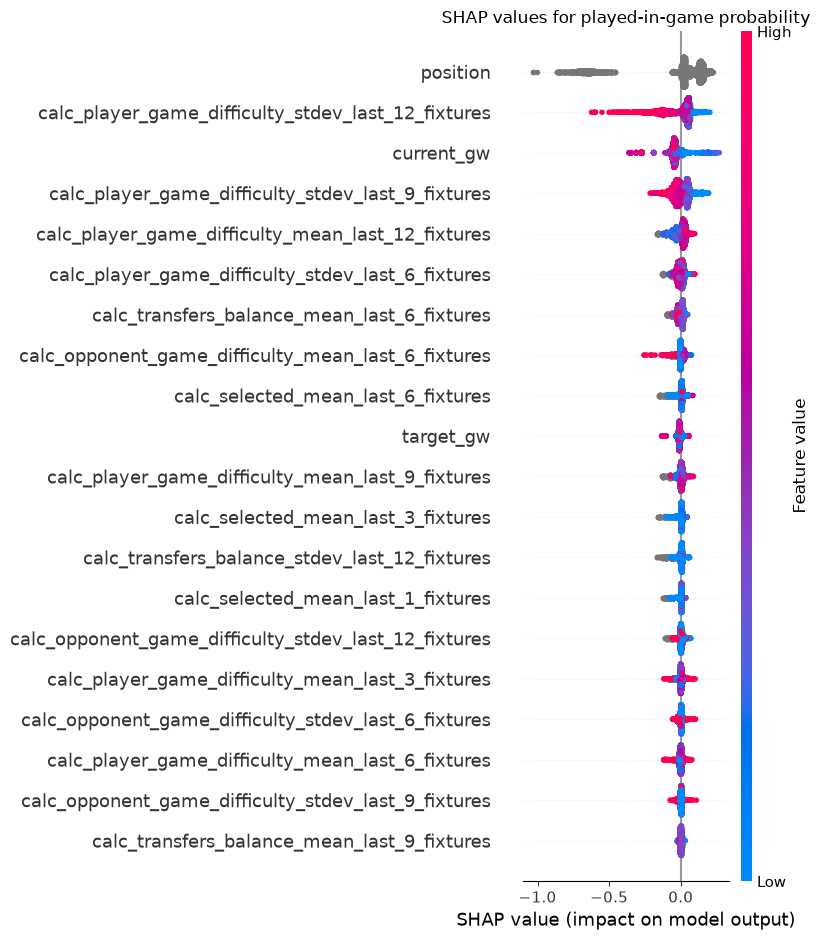

In [6]:
shap_sample_df = X_valid[selected_features].sample(
    n=min(10_000, len(X_valid)), random_state=RANDOM_STATE
)
shap_values = shap.TreeExplainer(selected_model)(shap_sample_df)
shap.plots.beeswarm(shap_values, max_display=len(selected_features), show=False)
plt.title("SHAP values for played-in-game probability")
plt.tight_layout()
plt.show()


In [7]:
save_trained_catboost_model(
    model=selected_model,
    feature_columns=selected_features,
    categorical_columns=selected_categorical_columns,
    model_name="Unweighted CatBoost played-in-game model - top 20 features",
    model_version="0.1.0",
    save_path=PLAYED_IN_GAME_ARTIFACT_PATH,
)
print(f"Saved played-in-game model to {PLAYED_IN_GAME_ARTIFACT_PATH}")


Saved played-in-game model to /Users/calumthompson/Documents/fantasy_football_v2/src/prediction/artifacts/trained_models/played_in_game_model.joblib
